In [ ]:
from langchain_core.messages import HumanMessage
from langgraph.types import Command 
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain.agents import create_agent 
from IPython.display import Image, display 
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.types import interrupt, Command
from langchain_core.messages import AIMessage, HumanMessage
from langgraph.graph import StateGraph
import json

from typing import Annotated, Sequence, List, Literal, TypedDict 
from pydantic import BaseModel, Field 
from operator import add

from typing import TypedDict, Literal, Optional

from db.crud import save_request
load_dotenv()

llm = ChatGoogleGenerativeAI(model='gemini-3.1-flash-lite')

from fastapi import FastAPI

from db.database import Base, engine
import db.models  

app = FastAPI()

Base.metadata.create_all(bind=engine)

In [ ]:
class Classification(BaseModel):
    classification: Literal[
            "Complaint",
            "General Enquiry",
            "Service Request",
            "Escalation"
        ]
    confidence: float
    reasoning: str

class ServiceRequestResponse(BaseModel):
    service_type: str
    extracted_details: str
    assigned_department: str
    confirmation_message: str
    
class EscalationResponse(BaseModel):
    escalation_reason: str
    supervisor_team: str
    acknowledgement: str

class RequestState(MessagesState):
    request: str
    response: str
    
    urgency: str
    classification: Classification

    assigned_team: str
    follow_up: str
    status: str
    highPriority: bool

    service_type:str
    service_details: str

    escalation_reason: str

    actions_taken: List[str]

In [12]:
complaint_config = {
    "assigned_team": "Senior Complaint Team",
    "status": "Escalated",
    "follow_up": "2 Hours",
    "actions_taken": [
                    "Acknowledgement Generated",
                    "Escalated to Senior Complaint Team",
                    "Priority Flag Added",
                    "Follow-up Reminder Created"
                ]
}

enquiry_config = {
    "assigned_team": "AI Knowledge Base",
    "status": "Resolved",
    "follow_up": "Not Required",
    "actions_taken": [
        "Enquiry Topic Identified",
        "Knowledge Base Searched",
        "AI Response Generated",
        "Request Marked as Resolved"
    ]
}

service_request_config = {
    "assigned_team": "Service Operations",
    "status": "Assigned",
    "follow_up": "24 Hours",
    "actions_taken": [
        "Service Request Details Extracted",
        "Assigned to Relevant Department",
        "Confirmation Message Generated",
        "SLA Timer Started"
    ]
}

escalation_config = {
    "status": "Escalated",
    "follow_up": "Immediate",
    "actions_taken": [
        "Critical Issue Identified",
        "Supervisor Alert Generated",
        "Urgent Acknowledgement Generated",
        "Human Review Required",
        "Auto Resolution Paused"
    ]
}

routes = {
        "Complaint": "complaint",
        "General Enquiry": "enquiry",
        "Service Request": "service",
        "Escalation": "escalation",
    }

knowledge_base = {
    "Business Hours": {
        "information": "Our customer support is available Monday to Friday, 9:00 AM to 6:00 PM IST."
    },
    "Refund Policy": {
        "information": "Refund requests can be raised within 30 days of purchase. Approved refunds are processed within 5-7 business days."
    },
    "Order Tracking": {
        "information": "Customers can track their order using the tracking link sent in the confirmation email or from the 'My Orders' section."
    },
    "Shipping": {
        "information": "Standard shipping takes 3-5 business days. Express shipping takes 1-2 business days."
    },
    "Payment Methods": {
        "information": "We accept Visa, Mastercard, American Express, UPI, Net Banking, and PayPal."
    },
    "Account Management": {
        "information": "Customers can update their profile, password, email, and saved addresses from the Account Settings page."
    },
    "Password Reset": {
        "information": "Users can reset their password by clicking 'Forgot Password' on the login page. A reset link will be sent to the registered email."
    },
    "Subscription": {
        "information": "Subscriptions can be cancelled anytime from the Subscription section. Benefits remain active until the current billing cycle ends."
    },
    "Return Policy": {
        "information": "Products can be returned within 15 days if they are unused and in their original packaging."
    },
    "Warranty": {
        "information": "All electronic products include a one-year manufacturer warranty covering manufacturing defects only."
    }
}

department_map = {
    "Address Change": "Customer Operations",
    "Subscription Cancellation": "Subscription Team",
    "Refund": "Billing Team",
    "Product Replacement": "Returns & Replacement Team",
    "Technical Support": "Technical Support Team",
    "Appointment Booking": "Scheduling Team",
    "Warranty Claim": "Warranty Team"
}

In [13]:
def classifier(state: RequestState) -> Command[Literal["complaint", "enquiry", "service", "escalation"]]:
    system_prompt = """
    You are an AI request classification agent.

    Your ONLY task is to analyze the user's request.

    Return:

    1. classification
    Complaint:
    - User expresses dissatisfaction.
    - Reports a bad experience.
    - Reports a defective product or poor service.

    General Enquiry:
    - User is asking for information.

    Service Request:
    - User wants something done.

    Escalation:
    - Serious issue requiring immediate attention.
    - Legal threat.
    - Data breach.
    - Fraud.
    - Manager complaint.

    2. confidence
    Between 0 and 1.

    3. reasoning
    One sentence explaining why.

    Do not generate responses for the customer.
    Do not solve the request.
    Only classify.
    """

    user_query = state["request"]
    if not user_query:
        return Command(
        update={
            "response": "Please provide a request."
        },
        goto=END
    )

    messages = [
        {"role":"system", "content":system_prompt},
        {"role":"user", "content":user_query}
    ]

    response = llm.with_structured_output(Classification).invoke(messages)

    urgency_map = {
        "Complaint": "High",
        "General Enquiry": "Low",
        "Service Request": "Medium",
        "Escalation": "Critical",
    }
    urgency = urgency_map[response.classification]


    print("=====================================")
    print(routes)
    print(response.classification)
    print(routes[response.classification])
    print("=====================================")


    
    return Command(
        update={
            "classification": response,
            "urgency":urgency  
        },
        goto = routes[response.classification]
    )

In [14]:
def complaint(state:RequestState):
    system_prompt = """
    You are a customer support agent.

    Generate a professional acknowledgement text response.

    Rules:
    - Do NOT write an email.
    - write a body, and regards

    Mention that:
        - complaint received
        - apology
        - escalated to senior support
        - someone will contact them shortly
        Don't invent any information.
    """

    messages = [
        {"role":"system", "content":system_prompt},
        {"role":"user", "content":state["request"]} 
    ]

    response = llm.invoke(messages)

    return Command(
        update={
            "response": response.content[0]["text"],
            "assigned_team": complaint_config["assigned_team"],
            "status": complaint_config["status"],
            "follow_up": complaint_config["follow_up"],
            "actions_taken": complaint_config["actions_taken"],
            "highPriority":True
        },
        goto = "logger"
    )

In [15]:
def enquiry(state:RequestState):
    system_prompt = f"""
    You are a customer support assistant.

    The user has submitted a general enquiry.
    Use ONLY the following knowledge base to answer the customer's enquiry.

    Knowledge Base: {knowledge_base}

    Your task is to:
    1. Identify the enquiry topic.
    2. Answer the user's question accurately.
    3. If the answer is unknown, politely state that the information is unavailable instead of inventing it.

    Rules:
    - If the answer exists in the knowledge base, answer using only that information.
    - If the answer is not present, respond:
    "I'm sorry, I couldn't find information related to your question. A support representative will assist you shortly."
    - Do not invent information.
    """

    messages = [
        {"role":"system", "content":system_prompt},
        {"role":"user", "content":state["request"]}
    ]

    response = llm.invoke(messages)

    return Command(
        update={
            "response": response.content[0]["text"],
            "assigned_team": enquiry_config["assigned_team"],
            "status": enquiry_config["status"],
            "follow_up": enquiry_config["follow_up"],
            "actions_taken": enquiry_config["actions_taken"],
            "highPriority":False
        },
        goto = "logger"
    )

In [31]:
def service(state:RequestState):
    system_prompt = f"""
        You are a customer support service request processor.

        Available departments:
        {department_map}

        Tasks:
        1. Identify the requested service.
        2. Extract the important details.
        3. Choose ONLY one department from the department map.
        4. Generate a confirmation message.

        Rules:
        - Do not invent department names.
        - If no department matches exactly, choose the closest one.
        - Do not generate an email.
        - Keep the confirmation message under 50 words.
    """

    messages = [
        {"role":"system", "content":system_prompt},
        {"role":"user", "content":state["request"]}
    ]

    response = llm.with_structured_output(ServiceRequestResponse).invoke(messages)

    return Command(
        update={
            "response": response.confirmation_message,
            "assigned_team": service_request_config["assigned_team"] + "-" + response.assigned_department,
            "status": service_request_config["status"],
            "follow_up": service_request_config["follow_up"],
            "actions_taken": service_request_config["actions_taken"],
            "service_type": response.service_type,
            "service_details": response.extracted_details,
            "highPriority": False,
        },
        goto = "logger"
    )



In [17]:
def escalation(state:RequestState):
    system_prompt = """
        You are an escalation handling agent.

        The user's request has already been classified as an Escalation.

        Your responsibilities are:

        1. Identify why the request requires escalation.
        2. Determine the most appropriate supervisor team.
        3. Generate a short acknowledgement.

        Rules:
        - Assume human intervention is required.
        - Do not attempt to resolve the issue.
        - Do not generate an email.
        - Do not include greetings or signatures.
        - Keep the acknowledgement under 50 words.
    """

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": state["request"]}
    ]

    response = llm.with_structured_output(EscalationResponse).invoke(messages)

    return Command(
        update={
            "response": response.acknowledgement,
            "assigned_team": response.supervisor_team,
            "status": escalation_config["status"],
            "follow_up": escalation_config["follow_up"],
            "actions_taken": escalation_config["actions_taken"],
            "highPriority": True,
            "escalation_reason": response.escalation_reason,
        },
        goto="logger"
    )


In [32]:
import json

def logger(state: RequestState):
    save_request(
        request=state["request"],

        classification=state["classification"].classification,
        urgency=state["urgency"],
        highPriority=state["highPriority"],

        assigned_team=state["assigned_team"],
        generated_response=state["response"],
        follow_up=state["follow_up"],
        status=state["status"],

        reasoning=state["classification"].reasoning,
        confidence=state["classification"].confidence,

        service_type=state.get("service_type"),
        service_details=state.get("service_details"),

        escalation_reason=state.get("escalation_reason"),

        actions_taken=json.dumps(
            state.get("actions_taken", [])
        )
    )

    return Command(goto=END)

In [33]:
builder = StateGraph(RequestState)

builder.add_node("classifier", classifier)
builder.add_node("complaint", complaint)
builder.add_node("enquiry", enquiry)
builder.add_node("service", service)
builder.add_node("escalation", escalation)
builder.add_node("logger", logger)

builder.add_edge(START, "classifier")
graph = builder.compile()

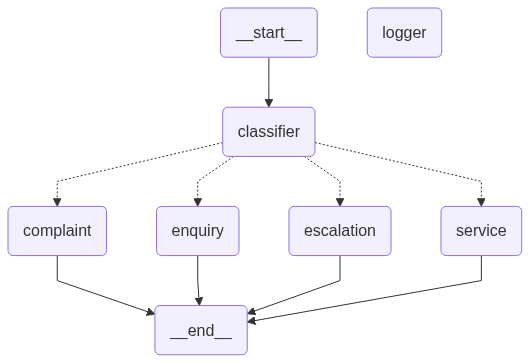

In [20]:
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [37]:
respose = graph.invoke(
    {
        "request":  "Your support team keeps closing my ticket without solving the problem.",
    }
)

print(respose)

{'Complaint': 'complaint', 'General Enquiry': 'enquiry', 'Service Request': 'service', 'Escalation': 'escalation'}
Escalation
escalation
{'messages': [], 'request': 'Your support team keeps closing my ticket without solving the problem.', 'response': 'I acknowledge that your ticket has been closed without a resolution. I am escalating this to our management team to review the handling of your case and ensure your concerns are addressed properly.', 'urgency': 'Critical', 'classification': Classification(classification='Escalation', confidence=0.95, reasoning='The user is reporting an unresolved issue after multiple attempts and expressing frustration with the support process, indicating a need for higher-level intervention.'), 'assigned_team': 'Customer Success Management', 'follow_up': 'Immediate', 'status': 'Escalated', 'highPriority': True, 'escalation_reason': 'Repeated premature closure of support tickets without issue resolution.', 'actions_taken': ['Critical Issue Identified', 'S